In [1]:
import torch
import pandas as pd
from torch_geometric.data import Data
from pathlib import Path
import os
os.chdir(Path().cwd().parent)
from modelling import get_dataframes
from modelling.metrics.metricstracker import MetricsTracker
import datetime
from graph_modelling.utils.load_data import load_train_val_data, load_test_data, read_csv_files


Running __init__.py for data pipeline...
Modelling package initialized

/opt/rocm/lib/libamd_smi.so: cannot open shared object file: No such file or directory
Unable to find amdsmi library try installing amd-smi-lib from your package manager


2025-04-09 17:26:35.086342: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-09 17:26:35.086404: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-09 17:26:35.086431: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-09 17:26:35.095880: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-09 17:26:36.101218: W tensorflow/compiler/

In [2]:
HABROK = bool(0)                  # set to True if using HABROK; it will print
                                  # all stdout to a .txt file to log progress
BASE_DIR = Path.cwd()
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_combined"
ALL_DIR = DATA_DIR / "all"

print("BASE_DIR: ", BASE_DIR)
print("MODEL_PATH: ", MODEL_PATH)
print("ALL_DIR: ", ALL_DIR)

torch.manual_seed(34)             # set seed for reproducibility

N_HOURS_U = 72                    # number of hours to use for input
N_HOURS_Y = 24                    # number of hours to predict
N_HOURS_STEP = 24                 # "sampling rate" in hours of the data; e.g. 24 
                                  # means sample an I/O-pair every 24 hours
                                  # the contaminants and meteorological vars
CONTAMINANTS = ['NO2', 'O3'] # 'PM10', 'PM25']

BASE_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN
MODEL_PATH:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/results/models
ALL_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/data/data_combined/all


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# tracker = MetricsTracker(
#     experiment_name='GNN',
#     log_dir=BASE_DIR / "src" / 'results' / 'energy_logs',
#     track_energy=True,
#     track_tensorboard=True,
#     track_memory=True,
#     verbose=True,
# )

cuda


In [4]:
def get_data_files(city_path, data_type):
    """
    Get all feature and label files for a city for a specific data type.

    Args:
        city_path (Path): Path to the city directory.
        data_type (str): Type of data (train, val, or test).

    Returns:
        tuple: Lists of feature and label files.
    """
    feature_files = sorted(
        [
            f
            for f in os.listdir(city_path)
            if f.startswith(data_type) and f.endswith("_u.csv")
        ]
    )

    label_files = sorted(
        [
            f
            for f in os.listdir(city_path)
            if f.startswith(data_type) and f.endswith("_y.csv")
        ]
    )

    return feature_files, label_files


def read_csv_files(
    city_path, feature_files, label_files, drop_datetime=True, city_name=None
):
    """
    Read feature and label CSV files.

    Args:
        city_path (Path): Path to the city directory.
        feature_files (list): List of feature file names.
        label_files (list): List of label file names.
        drop_datetime (bool, optional): Whether to drop DateTime column. Defaults to True.

    Returns:
        tuple: Lists of feature and label DataFrames.
    """
    feature_dfs = []
    label_dfs = []

    for feat_file, label_file in zip(feature_files, label_files):
        feat_df = pd.read_csv(os.path.join(city_path, feat_file), delimiter=";")
        label_df = pd.read_csv(os.path.join(city_path, label_file), delimiter=";")
        if city_name is not None:
            feat_df.insert(feat_df.columns.get_loc("DateTime") + 1, "city_name", city_name)
            label_df.insert(label_df.columns.get_loc("DateTime") + 1, "city_name", city_name)
        if drop_datetime:
            feat_df = feat_df.drop(columns=["DateTime"])
            label_df = label_df.drop(columns=["DateTime"])

        feature_dfs.append(feat_df)
        label_dfs.append(label_df)

    return feature_dfs, label_dfs


In [5]:
def minmax_normalize_arr(arr, arr_min, arr_max):
    # Normalize with provided min and max, with a small epsilon to avoid division by zero
    return (arr - arr_min) / (arr_max - arr_min + 1e-8)

In [6]:
cities = ["amsterdam", "rotterdam", "utrecht"]

def load_gnn_data(split_type="train", drop_datetime=True, save=False):
    f = pd.DataFrame()
    l = pd.DataFrame()
    for idx, city in enumerate(cities):
        x, y = get_data_files(ALL_DIR / city, split_type)
        x, y = read_csv_files(ALL_DIR / city, x, y, drop_datetime=drop_datetime, city_name=idx)
        for element in x:
            f = pd.concat([f, element], axis=0)
        for element in y:
            l = pd.concat([l, element], axis=0)
    if save:
        f.to_csv(ALL_DIR / "train_u.csv", index=False, sep=";")
        l.to_csv(ALL_DIR / "train_y.csv", index=False, sep=";")
    return f, l

X_train, y_train = load_gnn_data("train", drop_datetime=False)
X_val, y_val = load_gnn_data("val", drop_datetime=False)
X_test, y_test = load_gnn_data("test", drop_datetime=False)
X = pd.concat([X_train, X_val, X_test], axis=0)
y = pd.concat([y_train, y_val, y_test], axis=0)

print(X.shape, y.shape)


(63792, 10) (63792, 4)


In [7]:
X

,DateTime,city_name,NO2,O3,P,SQ,WD,Wvh,dewP,temp
0,2017-08-01 00:00:00,0,42.50,9.90,20.0,0.0,120.0,10.0,136.0,156.0
1,2017-08-01 01:00:00,0,38.80,12.10,20.0,0.0,0.0,10.0,136.0,144.0
2,2017-08-01 02:00:00,0,41.30,8.90,20.0,0.0,170.0,10.0,136.0,143.0
3,2017-08-01 03:00:00,0,22.80,17.90,10.0,0.0,130.0,10.0,124.0,129.0
4,2017-08-01 04:00:00,0,21.50,11.20,20.0,0.0,190.0,10.0,137.0,143.0
...,...,...,...,...,...,...,...,...,...,...
1507,2023-12-04 19:00:00,2,27.65,16.74,80.0,9.0,100.0,50.0,14.0,17.0
1508,2023-12-04 20:00:00,2,24.69,19.76,80.0,3.0,100.0,50.0,17.0,20.0
1509,2023-12-04 21:00:00,2,24.83,19.49,80.0,3.0,100.0,50.0,19.0,22.0
1510,2023-12-04 22:00:00,2,23.93,19.59,80.0,8.0,90.0,50.0,22.0,24.0


In [8]:
y

,DateTime,city_name,NO2,O3
0,2017-08-01 00:00:00,0,39.60,30.80
1,2017-08-01 01:00:00,0,33.10,37.10
2,2017-08-01 02:00:00,0,36.40,28.90
3,2017-08-01 03:00:00,0,35.10,21.10
4,2017-08-01 04:00:00,0,41.30,10.80
...,...,...,...,...
1507,2023-12-04 19:00:00,2,21.41,21.69
1508,2023-12-04 20:00:00,2,20.75,22.94
1509,2023-12-04 21:00:00,2,21.08,22.27
1510,2023-12-04 22:00:00,2,19.64,22.69


In [9]:
# Ensure data is sorted by time before reshaping
X_sorted = X.sort_values(by=["DateTime", "city_name"])  

# Reshape to (num_timesteps, 3, num_features)
num_timesteps = len(X_sorted) // 3  # Since we have 3 nodes per timestep
num_features = X_sorted.shape[1] - 2  # Exclude city_name
x = X_sorted.iloc[:, 2:].values.reshape(num_timesteps, 3, num_features)

# Convert to PyTorch tensor
x = torch.tensor(x, dtype=torch.float)

print("New Node Features Shape:", x.shape)  # Should be (num_timesteps, 3, num_features)


New Node Features Shape: torch.Size([21264, 3, 8])


In [10]:
y_sorted = y.sort_values(by=["DateTime", "city_name"])  
y = y_sorted.iloc[:, 2:].values.reshape(num_timesteps, 3, -1)  # (num_timesteps, 3, target_features)

# Convert to PyTorch tensor
y = torch.tensor(y, dtype=torch.float)

print("New Target Shape:", y.shape)  # Should be (num_timesteps, 3, 2) if 2 pollution targets
y

New Target Shape: torch.Size([21264, 3, 2])


tensor([[[39.6000, 30.8000],
         [66.3000,  2.3000],
         [22.0800, 19.6100]],

        [[33.1000, 37.1000],
         [67.6000,  1.0000],
         [14.8400, 23.7800]],

        [[36.4000, 28.9000],
         [58.1000,  0.9000],
         [26.9200, 16.1900]],

        ...,

        [[26.0000, 25.6000],
         [33.2000, 11.9000],
         [21.0800, 22.2700]],

        [[26.8000, 25.8000],
         [32.0000, 13.6000],
         [19.6400, 22.6900]],

        [[23.8000, 26.6000],
         [27.8000, 16.6000],
         [17.1100, 23.9600]]])

In [11]:

edge_index = torch.tensor([
    [0, 0, 1, 1, 2, 2],  # Source nodes
    [1, 2, 0, 2, 0, 1]   # Target nodes
], dtype=torch.long)

edge_index

tensor([[0, 0, 1, 1, 2, 2],
        [1, 2, 0, 2, 0, 1]])

In [12]:
def create_sliding_windows(X, Y, window_size, forecast_horizon):
    """
    X: (num_timesteps, 3, num_features) - Pollution data for 3 cities over time
    Y: (num_timesteps, 3, target_features) - Future pollution values to predict
    window_size: How many past timesteps to use
    forecast_horizon: How many timesteps into the future to predict
    """
    X_windows, Y_windows = [], []
    for i in range(len(X) - window_size - forecast_horizon + 1):
        X_windows.append(X[i : i + window_size])  # Past `window_size` timesteps
        Y_windows.append(Y[i + window_size : i + window_size + forecast_horizon])  # Predict next `forecast_horizon` steps
    
    return torch.stack(X_windows), torch.stack(Y_windows)

N_HOURS_U = 72   # Number of past hours to use (input window)
N_HOURS_Y = 24    # Number of future hours to predict (forecast horizon)

# Generate sliding window data
X_windows, Y_windows = create_sliding_windows(x, y, N_HOURS_U, N_HOURS_Y)

print(f"X_windows shape: {X_windows.shape}")  # Expected: (num_samples, 24, 3, num_features)
print(f"Y_windows shape: {Y_windows.shape}")  # Expected: (num_samples, 24, 3, target_features)


X_windows shape: torch.Size([21169, 72, 3, 8])
Y_windows shape: torch.Size([21169, 24, 3, 2])


In [13]:
num_samples, window_size, num_nodes, num_features = X_windows.shape
_, forecast_horizon, _, target_features = Y_windows.shape

# Flatten the input window per node:
X_windows_flat = X_windows.reshape(num_samples, num_nodes, window_size * num_features)
# Flatten the forecast horizon window into one target vector per node:
Y_windows_flat = Y_windows.reshape(num_samples, num_nodes, forecast_horizon * target_features)

print(f"X_windows_flat shape: {X_windows_flat.shape}")  # (num_samples, 3, window_size*num_features)
print(f"Y_windows_flat shape: {Y_windows_flat.shape}")  # (num_samples, 3, forecast_horizon*target_features)


X_windows_flat shape: torch.Size([21169, 3, 576])
Y_windows_flat shape: torch.Size([21169, 3, 48])


In [14]:
dataset = []
for i in range(num_samples):
    data = Data(
        x = X_windows_flat[i],         # shape: (3, window_size*num_features)
        edge_index = edge_index,         # same for every graph
        y = Y_windows_flat[i]            # shape: (3, forecast_horizon*target_features)
    )
    dataset.append(data)

print(f"Created dataset with {len(dataset)} graphs.")

Created dataset with 21169 graphs.


In [15]:
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

# Perform chronological split
train_dataset = dataset[:train_size]
val_dataset = dataset[train_size:train_size + val_size]
test_dataset = dataset[train_size + val_size:]

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 14818, Val: 3175, Test: 3176


In [16]:
# ------------------------------
# Compute min and max for x (features) and y (targets) using only the training set.
# We'll concatenate all training samples' x's and y's to compute global min and max.

def get_min_max(dataset, attr_name):
    # attr_name is 'x' or 'y'
    all_data = torch.cat([getattr(data, attr_name) for data in dataset], dim=0)  
    # all_data shape: (num_train_samples*3, feature_dim)
    arr = all_data.numpy()
    arr_min = arr.min(axis=0, keepdims=True)
    arr_max = arr.max(axis=0, keepdims=True)
    return arr_min, arr_max

x_min, x_max = get_min_max(train_dataset, 'x')
y_min, y_max = get_min_max(train_dataset, 'y')

print("x_min shape:", x_min.shape, "x_max shape:", x_max.shape)
print("y_min shape:", y_min.shape, "y_max shape:", y_max.shape)
print("x_min:", x_min)
print("x_max:", x_max)

x_min shape: (1, 576) x_max shape: (1, 576)
y_min shape: (1, 48) y_max shape: (1, 48)
x_min: [[  -2.5    -5.      0.      0.      0.      0.   -104.    -46.     -1.7
    -4.5     0.      0.      0.      0.    -86.    -46.      0.98   -2.22
     0.      0.      0.      0.   -106.    -61.     -2.5    -5.      0.
     0.      0.      0.   -104.    -46.     -1.7    -4.5     0.      0.
     0.      0.    -86.    -46.      0.98   -2.22    0.      0.      0.
     0.   -106.    -61.     -2.5    -5.      0.      0.      0.      0.
  -104.    -46.     -1.7    -4.5     0.      0.      0.      0.    -86.
   -46.      0.98   -2.22    0.      0.      0.      0.   -106.    -61.
    -2.5    -5.      0.      0.      0.      0.   -104.    -46.     -1.7
    -4.5     0.      0.      0.      0.    -86.    -46.      0.98   -2.22
     0.      0.      0.      0.   -106.    -61.     -2.5    -5.      0.
     0.      0.      0.   -104.    -46.     -1.7    -4.5     0.      0.
     0.      0.    -86.    -46.      

In [17]:
def normalize_dataset(dataset, x_min, x_max, y_min, y_max):
    for data in dataset:
        # Normalize x:
        x_arr = data.x.numpy()
        x_norm = minmax_normalize_arr(x_arr, x_min, x_max)
        data.x = torch.tensor(x_norm, dtype=torch.float)
        # Normalize y:
        y_arr = data.y.numpy()
        y_norm = minmax_normalize_arr(y_arr, y_min, y_max)
        data.y = torch.tensor(y_norm, dtype=torch.float)
    return dataset

# Normalize each split using the training-set min and max:
train_dataset = normalize_dataset(train_dataset, x_min, x_max, y_min, y_max)
val_dataset = normalize_dataset(val_dataset, x_min, x_max, y_min, y_max)
test_dataset = normalize_dataset(test_dataset, x_min, x_max, y_min, y_max)


In [18]:
train_dataset[0].x, train_dataset[0].y

(tensor([[0.4447, 0.0776, 0.0769,  ..., 0.0833, 0.7287, 0.5000],
         [0.3617, 0.1448, 0.1538,  ..., 0.1667, 0.7988, 0.5725],
         [0.1660, 0.2370, 0.3077,  ..., 0.3333, 0.7012, 0.5675]]),
 tensor([[0.0437, 0.3564, 0.0718, 0.3025, 0.1145, 0.2837, 0.0310, 0.3627, 0.0851,
          0.2587, 0.0798, 0.3031, 0.0310, 0.3408, 0.2560, 0.1131, 0.0967, 0.2718,
          0.0211, 0.3489, 0.2344, 0.1374, 0.1556, 0.2178, 0.0514, 0.3196, 0.2141,
          0.1380, 0.1957, 0.1936, 0.1176, 0.2821, 0.1944, 0.1494, 0.2971, 0.1855,
          0.1289, 0.2665, 0.1677, 0.1634, 0.2806, 0.1758, 0.1796, 0.2104, 0.2141,
          0.1180, 0.2536, 0.1754],
         [0.1648, 0.2422, 0.2103, 0.1304, 0.2055, 0.1979, 0.1120, 0.3027, 0.0794,
          0.2998, 0.1988, 0.2357, 0.1359, 0.3152, 0.0693, 0.3274, 0.2322, 0.2770,
          0.1359, 0.3695, 0.0534, 0.3804, 0.3092, 0.2801, 0.1148, 0.3983, 0.0781,
          0.3582, 0.1522, 0.3819, 0.1028, 0.4220, 0.0546, 0.3988, 0.1595, 0.4055,
          0.0965, 0.4713, 0.04

In [19]:
# Create DataLoaders for each split:
from torch_geometric.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

/home/nick/bachelor-project/forecasting_smog_DL_GNN/.venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [20]:
from graph_modelling.models.temporalgnn import TemporalGNN
input_dim = window_size * num_features
output_dim = forecast_horizon * target_features
model = TemporalGNN(input_dim=input_dim, output_dim=output_dim, hidden_dim=16)

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-6, weight_decay=0.00001)
patience = 20

criterion = torch.nn.MSELoss()
model

TemporalGNN(
  (conv1): GCNConv(576, 16)
  (conv2): GCNConv(16, 16)
  (rnn): GRU(16, 16, batch_first=True)
  (fc_out): Linear(in_features=16, out_features=48, bias=True)
)

In [21]:
from tqdm import tqdm
# --- Training Loop with Early Stopping ---
num_epochs = 500 # Increase max epochs, early stopping will likely trigger before this
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0 # Use a different variable name to avoid confusion

    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", unit="batch") as pbar:
        for batch in pbar:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            # Ensure output_dim is defined correctly based on flattening
            output_dim = Y_windows_flat.shape[-1] # Or recalculate based on N_HOURS_Y * target_features
            y_target = batch.y.view(-1, output_dim)

            if out.shape != y_target.shape:
                print(f"Shape mismatch: output {out.shape}, target {y_target.shape}")
                # Decide how to handle - skip batch or raise error
                continue # Skipping for now

            loss = criterion(out, y_target)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            pbar.set_postfix(loss=epoch_train_loss / (pbar.n + 1)) # Correct loss calculation for postfix

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    # Print training loss after the tqdm bar finishes for clarity
    # print(f"[Epoch {epoch+1}/{num_epochs}] Training Loss: {avg_train_loss:.6f}") # Optional: tqdm shows it

    # Validation phase
    model.eval()
    epoch_val_loss = 0 # Use a different variable name

    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", unit="batch") as pbar_val:
            for batch in pbar_val:
                batch = batch.to(device)
                out = model(batch)
                y_target = batch.y.view(-1, output_dim) # Use same output_dim

                if out.shape != y_target.shape:
                    print(f"Shape mismatch during validation: output {out.shape}, target {y_target.shape}")
                    continue # Skipping for now

                loss = criterion(out, y_target)
                epoch_val_loss += loss.item()
                pbar_val.set_postfix(loss=epoch_val_loss / (pbar_val.n + 1)) # Correct loss calculation

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"[Epoch {epoch+1}/{num_epochs}] Training Loss: {avg_train_loss:.6f} | Validation Loss: {avg_val_loss:.6f}")

    # --- Early Stopping Check ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"Validation loss did not improve. Patience counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break # Exit the training loop


Epoch 1/500 [Val]: 100%|██████████| 100/100 [00:00<00:00, 184.99batch/s, loss=0.098]


[Epoch 1/500] Training Loss: 0.106233 | Validation Loss: 0.095101


Epoch 2/500 [Val]: 100%|██████████| 100/100 [00:00<00:00, 139.51batch/s, loss=0.0983]


[Epoch 2/500] Training Loss: 0.103107 | Validation Loss: 0.092427


Epoch 3/500 [Val]: 100%|██████████| 100/100 [00:00<00:00, 146.23batch/s, loss=0.097]


...

[Epoch 130/500] Training Loss: 0.021094 | Validation Loss: 0.019289


Epoch 131/500 [Val]: 100%|██████████| 100/100 [00:00<00:00, 126.84batch/s, loss=0.0198]


[Epoch 131/500] Training Loss: 0.021033 | Validation Loss: 0.019237


Epoch 132/500 [Train]:   7%|▋         | 32/464 [00:00<00:07, 59.00batch/s, loss=0.0206]


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


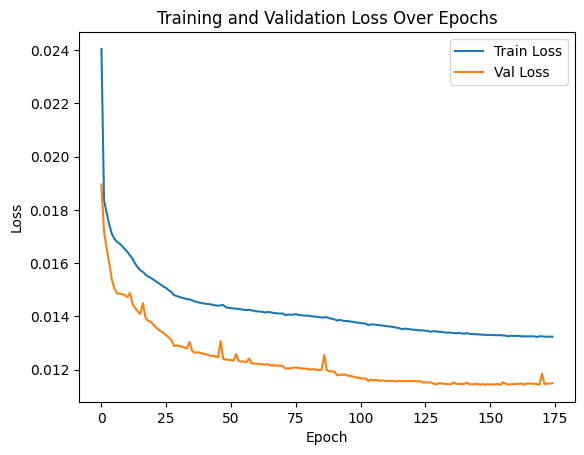

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss Over Epochs")
plt.show()


In [ ]:
# For example, if forecast_horizon=24 and target_features=2 then output_dim = 48.
output_dim = N_HOURS_Y * 2  # Adjust if needed

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)  # out shape: (batch_size * 3, output_dim)
        # The targets are stored in batch.y and need to be reshaped similarly.
        y_target = batch.y.view(-1, output_dim)
        
        all_preds.append(out.cpu())
        all_targets.append(y_target.cpu())

# Concatenate over all batches
all_preds = torch.cat(all_preds, dim=0)  # shape: (N, output_dim)
all_targets = torch.cat(all_targets, dim=0)  # shape: (N, output_dim)


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# Convert y_min and y_max to torch tensors. They were computed on the training set.
# They should have shape (1, output_dim) if computed per feature.
y_min_tensor = torch.tensor(y_min, dtype=torch.float)  # shape: (1, output_dim)
y_max_tensor = torch.tensor(y_max, dtype=torch.float)  # shape: (1, output_dim)

# Ensure the min/max tensors can broadcast over predictions and targets.
# Broadcasting will apply the scaling to each corresponding feature across the entire output dimension.
preds_unnorm = all_preds * (y_max_tensor - y_min_tensor) + y_min_tensor
targets_unnorm = all_targets * (y_max_tensor - y_min_tensor) + y_min_tensor

# --- Compute RMSE ---
# Global RMSE over all forecast values:
global_rmse = torch.sqrt(torch.mean((preds_unnorm - targets_unnorm) ** 2))

# To compute pollutant-specific RMSE, we need to separate the forecasts for NO2 and O3.
# Assume that for each node, the forecast vector is flattened as [NO2, O3, NO2, O3, ..., NO2, O3]
# and output_dim = forecast_horizon * 2.
# We'll reshape to: (N, forecast_horizon, 2)
preds_reshaped = preds_unnorm.view(-1, N_HOURS_Y, 2)
targets_reshaped = targets_unnorm.view(-1, N_HOURS_Y, 2)

# RMSE for NO2: (index 0) and O3: (index 1)
rmse_no2 = torch.sqrt(torch.mean((preds_reshaped[:, :, 0] - targets_reshaped[:, :, 0]) ** 2))
rmse_o3  = torch.sqrt(torch.mean((preds_reshaped[:, :, 1] - targets_reshaped[:, :, 1]) ** 2))

print(f"Global RMSE (unnormalized): {global_rmse.item():.4f}")
print(f"RMSE for NO2 (unnormalized): {rmse_no2.item():.4f}")
print(f"RMSE for O3 (unnormalized): {rmse_o3.item():.4f}")


Global RMSE (unnormalized): 17.2406
RMSE for NO2 (unnormalized): 14.0839
RMSE for O3 (unnormalized): 19.9028
